In [21]:
from collections import defaultdict
from itertools import count


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


from mesa import Model, Agent
from mesa.experimental.cell_space import Cell, CellAgent, OrthogonalMooreGrid
#from mesa.experimental.cell_space.cell import Cell #Wrong syntax
from mesa.datacollection import DataCollector
#from mesa.time import RandomActivation #not available in current version anymore



class Animal(CellAgent):

    def __init__(self, model, cell, energy_repro_treshold=4):
        super().__init__(model)
        assert isinstance(cell, Cell)
        self.energy_repro_treshold = energy_repro_treshold
        self.cell = cell
        self.energy = self.random.randrange(2, 6)

#Generate a chid asexually if energy is enough and there is empty space in the neighbourhoof
    def reproduce(self):
        empty = [cell for cell in self.cell.neighborhood if cell.is_empty]
        if (self.random.random() < self.p_reproduce) and (empty) and (self.energy >=self.energy_repro_treshold):
            child = self.__class__(self.model, self.random.choice(empty))

            energy = self.energy/2
            child.energy = energy
            self.energy = energy

    def get_neighbors(self):
        neighbors = defaultdict(list)
        for cell in self.cell.neighborhood:
            if cell.is_empty:
                neighbors['empty'].append(cell)
            else:
                for agent in cell.agents:
                    neighbors[agent.__class__].append(cell)            
        return neighbors
    
class Sheep(Animal):
    _instances = 0
    p_reproduce = 0.05
    
    @property
    def i(self):
        """convert the y-coordinate of the cell into the row index (i) 
        for the numpy array for the grass"""
        return self.cell.coordinate[1]
    
    @property
    def j(self):
        """convert the x-coordinate of the cell into the column index (j) 
        for the numpy array for the grass"""        
        return self.cell.coordinate[0]

    """
        Implement the right behaviour for sheep, allowing for movement, feeding and reproduction
    """
        
    def step(self):
        self.energy  -= 1

        #death
        if self.energy <= 0:
            self.remove()
            return

        # try to move
        try:
             cell = self.random.choice(self.get_neighbors()['empty'])
        except IndexError:
            pass
        else:
            self.cell = cell


        #gain more energy and remnove the grass from the cell
        # eat grass
        energy = self.model.grass[self.i, self.j]
        self.energy += energy
        self.model.grass[self.i, self.j] -= energy
        self.reproduce()


class Wolf(Animal):
    _instances = 0
    p_reproduce = 0.04
    
    def step(self):
        self.energy -= 1
        
        if self.energy <= 0:
            self.remove()
            return

        # try to move
        try:
             cell = self.random.choice(self.get_neighbors()[Sheep])
        except IndexError:
            pass
        else:
            self.cell = cell
            sheep = [agent for agent in self.cell.agents if isinstance(agent, Sheep)]
            sheep = self.random.choice(sheep)
            sheep.remove()
            self.energy += sheep.energy
            
        self.reproduce()


class PredatorPreyModel(Model):
    
    def __init__(self, width=20, height=20, sheep_density=0.20, wolf_density=0.01,
                regrowth_p=0.1, seed=None):
        super().__init__(seed=seed)
        Wolf._instances = 0
        Sheep._instances = 0
        self.width = width
        self.height = height
        self.regrowth_p = regrowth_p
        
        self.grid = OrthogonalMooreGrid((self.height, self.width), torus=True)
        self.grass = np.ones((self.height, self.width))
        self.datacollector = DataCollector({'wolves' : lambda m: len(m.agents_by_type[Wolf]),
                                            'sheep' : lambda m: len(m.agents_by_type[Sheep]),
                                            'grass' : lambda m: np.sum(m.grass)})
        
        n_cells = width * height
        n_sheep = int(round(sheep_density * n_cells))
        n_wolves = int(round(wolf_density * n_cells))
        
        for klass, n in ((Wolf, n_wolves),(Sheep, n_sheep)):
            for _ in range(n):
                agent = klass(self, self.random.choice(list(self.grid.empties)))
        
        self.datacollector.collect(self)
        
    def step(self):
        # regrow grass
        self.grass[self.grass != 0] += 1/3
        self.grass[(model.grass == 0) & (np.random.rand(*model.grass.shape) <= self.regrowth_p)] = 1/3
        self.grass = np.minimum(self.grass, 5)
        
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)



def visualize_model(model):
    green = sns.color_palette()[2] + (1,)
    red = sns.color_palette()[3] + (1,)
    transparent = sns.color_palette()[3] + (0,)
    
    x = []
    y = []
    colors = []
    for cell in model.grid.all_cells:
        x.append(cell.coordinate[0])
        y.append(cell.coordinate[1])
        
        if not cell.is_empty:
            color = red if isinstance(cell.agents[0], Wolf) else green
        else:
            color = transparent
        
        colors.append(color)
        
    sns.set_style('white')
    
    fig, ax = plt.subplots()
    ax.imshow(model.grass, vmin=0, vmax=5, cmap='viridis', origin='lower')
    ax.scatter(x,y, s=200, c=np.asarray(colors, dtype=object))
    ax.set_aspect('equal')
    # ax.set_xticks([])
    # ax.set_yticks([])
    
    return fig
    
    

/Users/precupada/Documents/Academics/Masters/EPA/Year 2/Q3/EPA123 Intro to TPM/ABM/venv/lib/python3.13/site-packages/mesa/discrete_space/grid.py:101: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


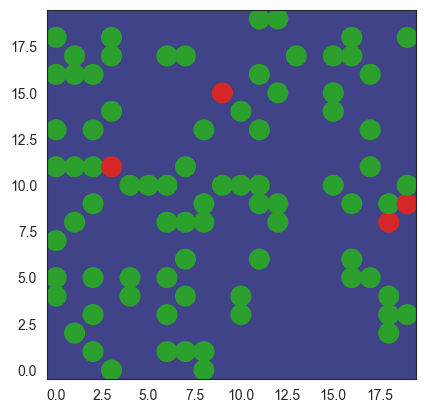

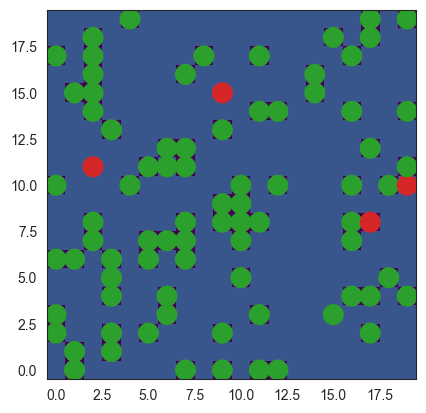

In [22]:
model = PredatorPreyModel()
visualize_model(model)
model.step()
visualize_model(model)
plt.show()

/Users/precupada/Documents/Academics/Masters/EPA/Year 2/Q3/EPA123 Intro to TPM/ABM/venv/lib/python3.13/site-packages/mesa/discrete_space/grid.py:101: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


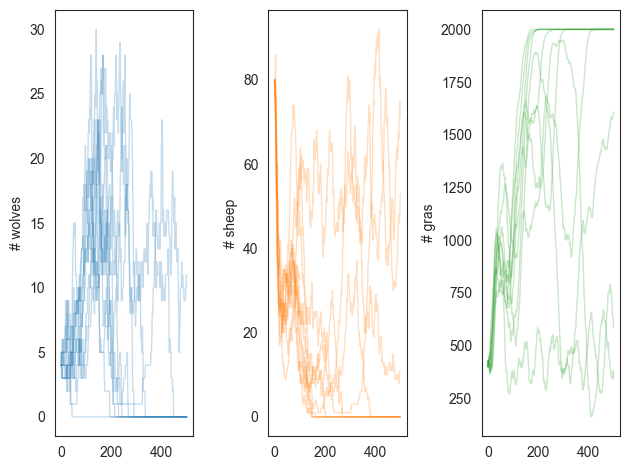

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3)
ax1.set_ylabel('# wolves')
ax2.set_ylabel('# sheep')
ax3.set_ylabel('# gras')    

for i in range(10):

    model = PredatorPreyModel(seed=i)
    for _ in range(500):
        model.step()
    data = model.datacollector.get_model_vars_dataframe()
    ax1.plot(data.wolves, color=sns.color_palette()[0], lw=1, alpha=0.25)
    ax2.plot(data.sheep, color=sns.color_palette()[1], lw=1, alpha=0.25)
    ax3.plot(data.grass, color=sns.color_palette()[2], lw=1, alpha=0.25)

#change_fontsize(fig, 14)
plt.tight_layout()
plt.show()





# experiments

change regrowth probability and ask to explain behavior in terms of delays....

### Dessertification

To include the circularity of nutrients in the environment, we can add a new attribute to follow nutritients level. This can help us better schedule an event for the regrowth of grass after it has been eaten, based on soil fertility. This way, we can have a more realistic model of the environment, where the grass does not regrow immediately after being eaten, but rather after a certain delay. We can also quantify the amount of nutrients being returned into the soil after the grass has been eaten. This way, we can have a more complete model of the ecosystem, where the manure is also taken into account in the dynamics of the system. We also need to account for the loss of nutrients if grass is not eaten and dies, which can lead to desertification. We can include a new parameter for model.desertification_rate, which can quantify the rate at which nutrients are lost from the soil.

### Modifications to model

Keep the existing grid for sheep and wolves, and keep grass as a NumPy layer, but add a second NumPy layer:
	•	model.nutrients[i, j]
Add parameters such as:
	•	nutrient_max → maximum nutrient stock per cell
	•	manure_return → nutrients returned when sheep eat grass
	•	nutrient_loss_rate → nutrient depletion when grass is not grazed / dries out
	•	grass_growth_efficiency → how strongly nutrient stock supports grass regrowth
	•	optionally dry_grass_threshold or a simple rule for uneaten grass decay
Modify grass so it no longer regrows only from the current fixed probability rule.
Change the sheep step so that when a sheep eats grass:
	•	a fraction of that consumed biomass is added back into model.nutrients[i, j]

# Observing behviour sensitivity to grass regrowth probability

In [26]:
regrowth_values = np.arange(0.05, 0.1501, 0.025)  # 0.05, 0.075, 0.10, 0.125, 0.15
n_seeds = 10
n_steps = 500
burn_in = 200

rows = []
"""
    Set up the run function for the regrowth range and collect data about:

    - the variation of animal populations across scenarios (average popualtions and std deviations)
    - the occurance rate of extinction events for wolves and sheep across scenarios
"""
for r in regrowth_values:
    for seed in range(n_seeds):
        model = PredatorPreyModel(regrowth_p=float(r), seed=seed)

        wolves_ts, sheep_ts, grass_ts = [], [], []

        for _ in range(n_steps):
            model.step()
            wolves_ts.append(len(model.agents_by_type[Wolf]))
            sheep_ts.append(len(model.agents_by_type[Sheep]))
            grass_ts.append(model.grass.sum())

        # use only post-burn period
        w = np.array(wolves_ts)
        s = np.array(sheep_ts)
        g = np.array(grass_ts)

        rows.append({
            "regrowth_p": float(r),
            "seed": seed,
            "wolves_mean": w.mean(),
            "sheep_mean": s.mean(),
            "grass_mean": g.mean(),
            "wolves_std": w.std(),
            "sheep_std": s.std(),
            "grass_std": g.std(),
            "wolves_extinct": int((w == 0).any()),
            "sheep_extinct": int((s == 0).any()),
        })

results = pd.DataFrame(rows)
results.head()

/Users/precupada/Documents/Academics/Masters/EPA/Year 2/Q3/EPA123 Intro to TPM/ABM/venv/lib/python3.13/site-packages/mesa/discrete_space/grid.py:101: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


,regrowth_p,seed,wolves_mean,sheep_mean,grass_mean,wolves_std,sheep_std,grass_std,wolves_extinct,sheep_extinct
0,0.05,0,7.834,18.570,992.050667,3.705461,11.347119,229.876759,0,0
1,0.05,1,5.578,26.166,759.752667,3.613297,11.135818,227.389427,0,0
2,0.05,2,7.162,22.314,879.865333,4.286229,10.126964,251.341963,0,0
3,0.05,3,6.598,19.432,1020.748000,4.108089,14.469049,400.001210,0,0
4,0.05,4,6.616,17.334,1112.624000,3.895708,13.500905,390.969832,0,0


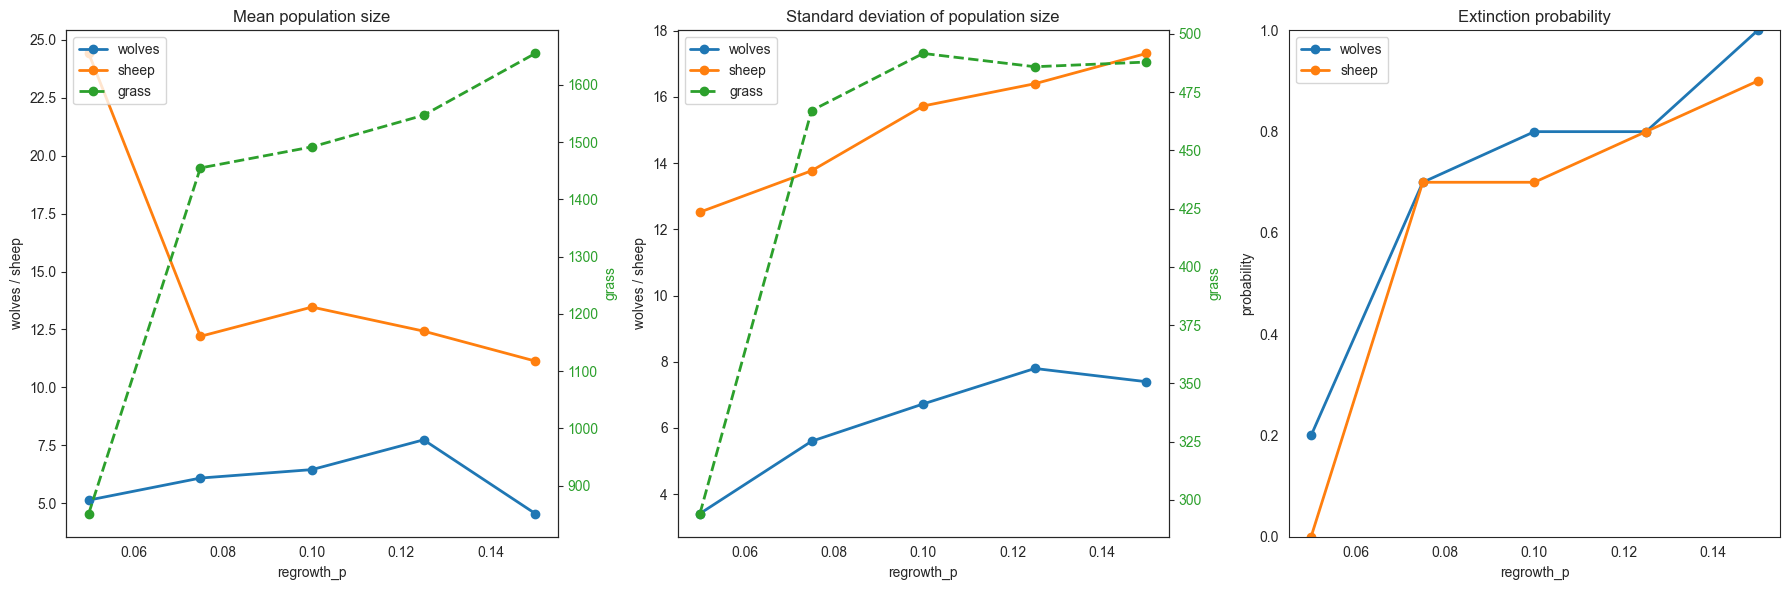

In [31]:
#Plot results of run

summary = results.groupby("regrowth_p", as_index=False).agg({
    "wolves_mean": "mean",
    "sheep_mean": "mean",
    "grass_mean": "mean",
    "wolves_std": "mean",
    "sheep_std": "mean",
    "grass_std": "mean",
    "wolves_extinct": "mean", #fraction of runs with extinction = extinction probability
    "sheep_extinct": "mean",
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

grass_mean_ax = axes[0].twinx()
grass_std_ax = axes[1].twinx()

# 1) Mean levels
axes[0].plot(summary["regrowth_p"], summary["wolves_mean"], marker="o", linewidth=2, label="wolves")
axes[0].plot(summary["regrowth_p"], summary["sheep_mean"], marker="o", linewidth=2, label="sheep")
grass_mean_ax.plot(summary["regrowth_p"], summary["grass_mean"], marker="o", linewidth=2, linestyle="--", color="tab:green", label="grass")
axes[0].set_title("Mean population size")
axes[0].set_xlabel("regrowth_p")
axes[0].set_ylabel("wolves / sheep")
grass_mean_ax.set_ylabel("grass", color="tab:green")
grass_mean_ax.tick_params(axis="y", labelcolor="tab:green")
lines, labels = axes[0].get_legend_handles_labels()
grass_lines, grass_labels = grass_mean_ax.get_legend_handles_labels()
axes[0].legend(lines + grass_lines, labels + grass_labels, loc="upper left")

# 2) Variability
axes[1].plot(summary["regrowth_p"], summary["wolves_std"], marker="o", linewidth=2, label="wolves")
axes[1].plot(summary["regrowth_p"], summary["sheep_std"], marker="o", linewidth=2, label="sheep")
grass_std_ax.plot(summary["regrowth_p"], summary["grass_std"], marker="o", linewidth=2, linestyle="--", color="tab:green", label="grass")
axes[1].set_title("Standard deviation of population size")
axes[1].set_xlabel("regrowth_p")
axes[1].set_ylabel("wolves / sheep")
grass_std_ax.set_ylabel("grass", color="tab:green")
grass_std_ax.tick_params(axis="y", labelcolor="tab:green")
lines, labels = axes[1].get_legend_handles_labels()
grass_lines, grass_labels = grass_std_ax.get_legend_handles_labels()
axes[1].legend(lines + grass_lines, labels + grass_labels, loc="upper left")

# 3) Extinction probability
axes[2].plot(summary["regrowth_p"], summary["wolves_extinct"], marker="o", linewidth=2, label="wolves")
axes[2].plot(summary["regrowth_p"], summary["sheep_extinct"], marker="o", linewidth=2, label="sheep")
axes[2].set_title("Extinction probability")
axes[2].set_xlabel("regrowth_p")
axes[2].set_ylabel("probability")
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()

The results show that increasing the grass regrowth probability leads to higher average population sizes, especially for grass and sheep. As a consequence, higher regrowth probabilities are associated with a higher probability of extinction for both sheep and wolves. This suggests that more abundant resources can lead to stronger population fluctuations, making the system less stable over time.